# TP3 — Modelos Clásicos de Clasificación de Sentimiento

**Alumno:** Gonzalo Zarazaga

---

Este notebook cubre los primeros dos enfoques del README:

- **Enfoque 1**: baseline pre-entrenado (`TextBlob`), sin entrenamiento propio.
- **Enfoque 2**: representaciones dispersas — BoW + Naive Bayes, y TF-IDF + Logistic Regression, entrenados sobre el archivo de entrenamiento completo.

Ambos se evalúan contra dos conjuntos: el split de validación del archivo grande, y el test externo out-of-sample (`test_manual_processed.csv`, ver `00_lectura_y_discovery.ipynb`).

**Insumo:** `data/processed/train_processed.csv.gz`, `data/processed/test_manual_processed.csv`
**Salida:** tabla comparativa de métricas (Accuracy, F1, AUC), a extender en `04_clasificacion_w2v.ipynb` con Word2Vec+LR.

## 1. Carga de datos

In [1]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from textblob import TextBlob
import nltk
from nltk.corpus import stopwords

df_train_full = pd.read_csv("../data/processed/train_processed.csv.gz")
df_test_manual = pd.read_csv("../data/processed/test_manual_processed.csv")

print(f"train (completo): {len(df_train_full):,} filas")
print(f"test manual:       {len(df_test_manual):,} filas")

train (completo): 1,578,449 filas
test manual:       359 filas


## 2. Split train/validación

**Convención fija para todo el TP** (se reutiliza igual en `03_word2vec.ipynb` y `04_clasificacion_w2v.ipynb` para que la comparación final entre los cuatro modelos sea justa): `test_size=0.2`, `random_state=42`, estratificado por `polarity`, sobre `train_processed.csv.gz`.

La polaridad se mapea a binario (`0`→0, `4`→1) para simplificar las métricas; el test manual usa el mismo mapeo.

In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.2

df_train_full["label"] = (df_train_full["polarity"] == 4).astype(int)
df_test_manual["label"] = (df_test_manual["polarity"] == 4).astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    df_train_full["tokens"].astype(str),
    df_train_full["label"],
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_train_full["label"],
)

X_manual = df_test_manual["tokens"].astype(str)
y_manual = df_test_manual["label"]

print(f"train: {len(X_train):,}  val: {len(X_val):,}  manual: {len(X_manual):,}")

train: 1,262,759  val: 315,690  manual: 359


In [3]:
def evaluar(nombre, y_true, y_pred, y_score):
    return {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "auc": roc_auc_score(y_true, y_score),
    }

resultados_val = []
resultados_manual = []

## 3. Enfoque 1 — Baseline pre-entrenado (TextBlob)

Se aplica `TextBlob(...).sentiment.polarity` directamente sobre los tokens ya limpios (sin entrenamiento propio). Es un score continuo en `[-1, 1]`; se usa como score para AUC y se umbraliza en 0 para la clase predicha. Sirve como cota inferior de referencia.

In [4]:
t0 = time.time()

def score_textblob(tokens_series):
    return tokens_series.apply(lambda t: TextBlob(t).sentiment.polarity)

score_val_tb = score_textblob(X_val)
pred_val_tb = (score_val_tb >= 0).astype(int)

score_manual_tb = score_textblob(X_manual)
pred_manual_tb = (score_manual_tb >= 0).astype(int)

t_textblob = time.time() - t0

resultados_val.append(evaluar("TextBlob (baseline)", y_val, pred_val_tb, score_val_tb))
resultados_manual.append(evaluar("TextBlob (baseline)", y_manual, pred_manual_tb, score_manual_tb))

print(f"TextBlob sobre {len(X_val) + len(X_manual):,} tweets (val + manual): {t_textblob:.1f}s")
print(classification_report(y_val, pred_val_tb, target_names=["Negativo", "Positivo"]))

TextBlob sobre 316,049 tweets (val + manual): 38.4s
              precision    recall  f1-score   support

    Negativo       0.76      0.32      0.45    157729
    Positivo       0.57      0.90      0.70    157961

    accuracy                           0.61    315690
   macro avg       0.67      0.61      0.58    315690
weighted avg       0.67      0.61      0.58    315690



## 4. Enfoque 2 — Representaciones dispersas

**Stopwords sin negaciones:** se remueven stopwords de NLTK para BoW/TF-IDF (no para Word2Vec, ver `01_preprocesamiento.ipynb`), excluyendo explícitamente palabras de negación (`not`, `no`, `never`, `don't`, etc.) porque invierten la polaridad del tweet — quitarlas destruiría la señal más importante para este problema.

**Vocabulario acotado** (`max_features=30000`, `min_df=5`): el vocabulario crudo de Twitter es enorme por errores de tipeo y jerga; limitarlo evita sobreajuste a términos que aparecen una sola vez y mantiene el entrenamiento tratable.

In [5]:
nltk.download("stopwords", quiet=True)

NEGACIONES = {
    "no", "nor", "not", "never",
    "aren't", "couldn't", "didn't", "doesn't", "don't", "hadn't", "hasn't",
    "haven't", "isn't", "mightn't", "mustn't", "needn't", "shan't",
    "shouldn't", "wasn't", "weren't", "won't", "wouldn't",
}
stopwords_en = stopwords.words("english")
STOPWORDS_SIN_NEGACION = sorted(set(stopwords_en) - NEGACIONES)

VECTORIZER_KWARGS = dict(max_features=30000, min_df=5, stop_words=STOPWORDS_SIN_NEGACION)
print(f"Stopwords aplicadas: {len(STOPWORDS_SIN_NEGACION)} (de {len(stopwords_en)}, se excluyeron {len(NEGACIONES)} negaciones)")

Stopwords aplicadas: 177 (de 198, se excluyeron 22 negaciones)


### 4.1 BoW + Naive Bayes

In [6]:
t0 = time.time()
count_vec = CountVectorizer(**VECTORIZER_KWARGS)
X_train_bow = count_vec.fit_transform(X_train)

nb = MultinomialNB()
nb.fit(X_train_bow, y_train)
t_bow_nb = time.time() - t0

pred_train_nb = nb.predict(X_train_bow)

X_val_bow = count_vec.transform(X_val)
pred_val_nb = nb.predict(X_val_bow)
score_val_nb = nb.predict_proba(X_val_bow)[:, 1]

X_manual_bow = count_vec.transform(X_manual)
pred_manual_nb = nb.predict(X_manual_bow)
score_manual_nb = nb.predict_proba(X_manual_bow)[:, 1]

resultados_val.append(evaluar("BoW + Naive Bayes", y_val, pred_val_nb, score_val_nb))
resultados_manual.append(evaluar("BoW + Naive Bayes", y_manual, pred_manual_nb, score_manual_nb))

print(f"Vocabulario BoW: {len(count_vec.vocabulary_):,} términos")
print(f"Vectorización + entrenamiento: {t_bow_nb:.1f}s (sobre {X_train.shape[0]:,} tweets)")

print("--- Train ---")
print(classification_report(y_train, pred_train_nb, target_names=["Negativo", "Positivo"]))
print("--- Validación ---")
print(classification_report(y_val, pred_val_nb, target_names=["Negativo", "Positivo"]))
print("--- Test manual ---")
print(classification_report(y_manual, pred_manual_nb, target_names=["Negativo", "Positivo"]))

Vocabulario BoW: 30,000 términos
Vectorización + entrenamiento: 14.4s (sobre 1,262,759 tweets)
--- Train ---


              precision    recall  f1-score   support

    Negativo       0.78      0.78      0.78    630915
    Positivo       0.78      0.78      0.78    631844

    accuracy                           0.78   1262759
   macro avg       0.78      0.78      0.78   1262759
weighted avg       0.78      0.78      0.78   1262759

--- Validación ---
              precision    recall  f1-score   support

    Negativo       0.77      0.78      0.77    157729
    Positivo       0.78      0.77      0.77    157961

    accuracy                           0.77    315690
   macro avg       0.77      0.77      0.77    315690
weighted avg       0.77      0.77      0.77    315690

--- Test manual ---
              precision    recall  f1-score   support

    Negativo       0.82      0.80      0.81       177
    Positivo       0.81      0.82      0.82       182

    accuracy                           0.81       359
   macro avg       0.81      0.81      0.81       359
weighted avg       0.81      0.81  

### 4.2 TF-IDF + Logistic Regression

In [7]:
t0 = time.time()
tfidf_vec = TfidfVectorizer(**VECTORIZER_KWARGS)
X_train_tfidf = tfidf_vec.fit_transform(X_train)

lr = LogisticRegression(max_iter=200, solver="liblinear", random_state=RANDOM_STATE)
lr.fit(X_train_tfidf, y_train)
t_tfidf_lr = time.time() - t0

pred_train_lr = lr.predict(X_train_tfidf)

X_val_tfidf = tfidf_vec.transform(X_val)
pred_val_lr = lr.predict(X_val_tfidf)
score_val_lr = lr.predict_proba(X_val_tfidf)[:, 1]

X_manual_tfidf = tfidf_vec.transform(X_manual)
pred_manual_lr = lr.predict(X_manual_tfidf)
score_manual_lr = lr.predict_proba(X_manual_tfidf)[:, 1]

resultados_val.append(evaluar("TF-IDF + Logistic Regression", y_val, pred_val_lr, score_val_lr))
resultados_manual.append(evaluar("TF-IDF + Logistic Regression", y_manual, pred_manual_lr, score_manual_lr))

print(f"Vectorización + entrenamiento: {t_tfidf_lr:.1f}s (sobre {X_train.shape[0]:,} tweets)")

print("--- Train ---")
print(classification_report(y_train, pred_train_lr, target_names=["Negativo", "Positivo"]))
print("--- Validación ---")
print(classification_report(y_val, pred_val_lr, target_names=["Negativo", "Positivo"]))
print("--- Test manual ---")
print(classification_report(y_manual, pred_manual_lr, target_names=["Negativo", "Positivo"]))

Vectorización + entrenamiento: 42.3s (sobre 1,262,759 tweets)
--- Train ---


              precision    recall  f1-score   support

    Negativo       0.81      0.78      0.79    630915
    Positivo       0.79      0.81      0.80    631844

    accuracy                           0.80   1262759
   macro avg       0.80      0.80      0.80   1262759
weighted avg       0.80      0.80      0.80   1262759

--- Validación ---
              precision    recall  f1-score   support

    Negativo       0.80      0.77      0.78    157729
    Positivo       0.78      0.80      0.79    157961

    accuracy                           0.79    315690
   macro avg       0.79      0.79      0.79    315690
weighted avg       0.79      0.79      0.79    315690

--- Test manual ---
              precision    recall  f1-score   support

    Negativo       0.81      0.76      0.79       177
    Positivo       0.78      0.83      0.81       182

    accuracy                           0.80       359
   macro avg       0.80      0.80      0.80       359
weighted avg       0.80      0.80  

## 5. Matrices de confusión (validación)

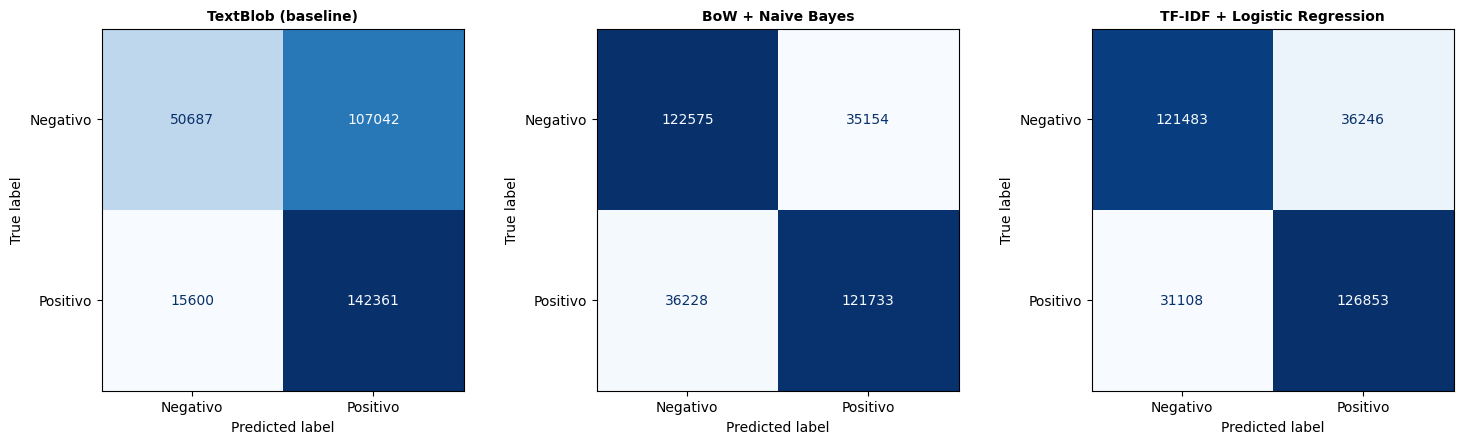

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

preds = [
    ("TextBlob (baseline)", pred_val_tb),
    ("BoW + Naive Bayes", pred_val_nb),
    ("TF-IDF + Logistic Regression", pred_val_lr),
]

for ax, (nombre, pred) in zip(axes, preds):
    cm = confusion_matrix(y_val, pred)
    ConfusionMatrixDisplay(cm, display_labels=["Negativo", "Positivo"]).plot(
        ax=ax, colorbar=False, cmap="Blues"
    )
    ax.set_title(nombre, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

## 6. Curvas ROC (validación)

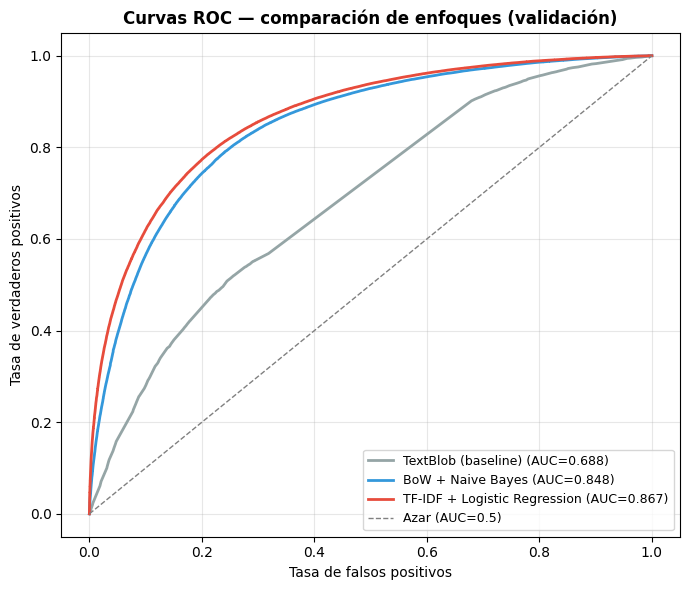

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

scores = [
    ("TextBlob (baseline)", score_val_tb, "#95a5a6"),
    ("BoW + Naive Bayes", score_val_nb, "#3498db"),
    ("TF-IDF + Logistic Regression", score_val_lr, "#e74c3c"),
]

for nombre, score, color in scores:
    fpr, tpr, _ = roc_curve(y_val, score)
    auc = roc_auc_score(y_val, score)
    ax.plot(fpr, tpr, label=f"{nombre} (AUC={auc:.3f})", color=color, linewidth=2)

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1, label="Azar (AUC=0.5)")
ax.set_xlabel("Tasa de falsos positivos")
ax.set_ylabel("Tasa de verdaderos positivos")
ax.set_title("Curvas ROC — comparación de enfoques (validación)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Tabla comparativa

Se compara cada modelo en dos conjuntos: el split de validación (mismo origen que el train, etiquetado automático) y el test manual (out-of-sample, etiquetado con una metodología distinta a la del train — ver `00_lectura_y_discovery.ipynb`). Una caída fuerte de métricas en el segundo indicaría que el modelo no generaliza más allá del heurístico de etiquetado por emoticon.

In [10]:
tabla_val = pd.DataFrame(resultados_val).set_index("modelo").add_suffix("_val")
tabla_manual = pd.DataFrame(resultados_manual).set_index("modelo").add_suffix("_manual")

tabla_comparativa = tabla_val.join(tabla_manual).round(4)
tabla_comparativa.to_csv("../data/processed/comparacion_enfoques.csv")
tabla_comparativa

,accuracy_val,f1_val,auc_val,accuracy_manual,f1_manual,auc_manual
modelo,,,,,,
TextBlob (baseline),0.6115,0.6989,0.6879,0.6880,0.7522,0.7974
BoW + Naive Bayes,0.7739,0.7733,0.8479,0.8106,0.8152,0.8881
TF-IDF + Logistic Regression,0.7866,0.7902,0.8667,0.7967,0.8053,0.8911


## 8. Conclusiones y decisiones

- **TextBlob** funciona como cota inferior: no fue entrenado sobre este corpus, por lo que su desempeño marca el piso que cualquier modelo entrenado debería superar.
- **Stopwords sin negaciones**: se excluyeron intencionalmente `not`, `no`, `never`, `don't`, etc. de la lista de stopwords — son la señal más fuerte para invertir la polaridad de un tweet corto.
- **Vocabulario acotado** (`max_features=30000`, `min_df=5`): mantiene el entrenamiento tratable sobre 1,26M documentos sin perder los términos frecuentes que realmente discriminan sentimiento.
- **Split fijo** (`random_state=42`, `test_size=0.2`, estratificado): se reutiliza igual en `03_word2vec.ipynb` y `04_clasificacion_w2v.ipynb`, para que la tabla comparativa final entre los cuatro modelos (TextBlob, BoW+NB, TF-IDF+LR, Word2Vec+LR) sea una comparación justa sobre el mismo conjunto de validación.
- **Test manual**: sirve para chequear generalización más allá del heurístico de etiquetado por emoticon del train, no para rankear modelos con precisión (n=359, IC 95% ±\~4pp — ver `04_clasificacion_w2v.ipynb`, sección 6.1) — ver la sección 7 para si hay una caída de métricas relevante entre validación y test manual.

Próximo paso: `03_word2vec.ipynb` entrena Word2Vec sobre el corpus y explora el espacio semántico aprendido.